In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib import cm
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import torch
from torch.optim import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from caleb.vae.model import VAE
from caleb.vae.train import Trainer
from caleb.vae.loss_criterion import loss_criterion
from caleb.vae.utils import get_optimal_device, save_checkpoint, load_checkpoint
from caleb.config import DATA_DIR, CKPT_DIR

In [2]:
torch.mps.empty_cache()
# Training params
epochs = 25
batch_size = 128
lr = 0.001

device = get_optimal_device()

# Model params
input_dim = 784
hidden_dim= 512
latent_dim = 200  # 10

vae_mnist_path = os.path.join(CKPT_DIR, "vae_mnist.pth")

print(f"Device: {device}")
print(f"Data path: {DATA_DIR}")
print(f"Ckpt path: {vae_mnist_path}")

Device: mps
Data path: /Users/calebdanielsen/SoftwareDevelopment/Learning/Machine Learning/VAE/caleb/data_mnist
Ckpt path: /Users/calebdanielsen/SoftwareDevelopment/Learning/Machine Learning/VAE/caleb/ckpt/vae_mnist.pth


In [3]:
# Load data set
train_dataset = MNIST(DATA_DIR, train=True, transform=ToTensor(), download=True)
test_dataset = MNIST(DATA_DIR, train=False, transform=ToTensor(), download=True)

# Create data loader
train_data_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_data_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [4]:
# Initialize model
model = VAE(input_dim, hidden_dim, latent_dim).to(device)

# Initialize optimizer
optimizer = Adam(model.parameters(), lr=lr)

In [5]:
# Initialize trainer
trainer = Trainer(model=model,
                  optimizer=optimizer,
                  loss_fn=loss_criterion,
                  device=device)

In [6]:
train_losses, val_losses, train_recon_losses, train_kl_losses, epoch_step, global_step = trainer.run_training(train_data_loader, test_data_loader, epochs=epochs)

  0%|          | 0/25 [00:00<?, ?it/s]

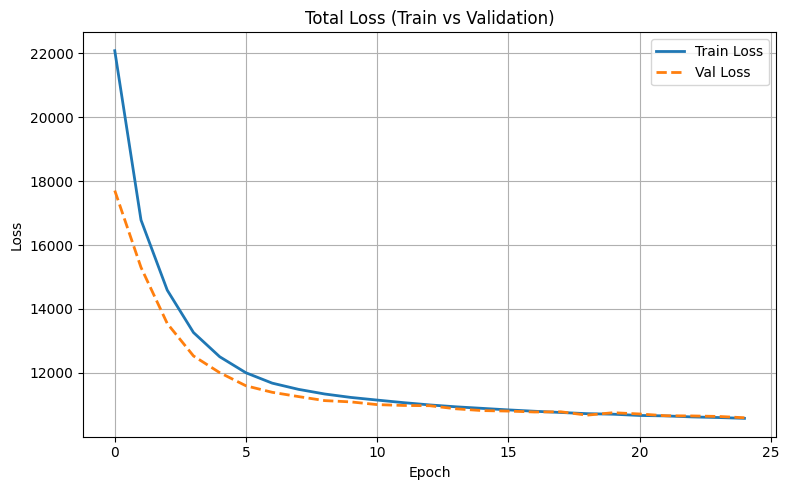

In [7]:
epochs_range = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Val Loss", linewidth=2, linestyle="--")
plt.title("Total Loss (Train vs Validation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()


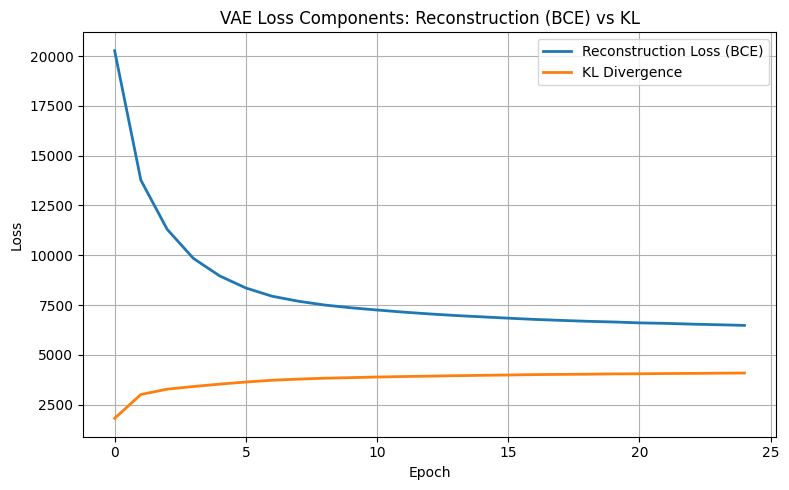

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(train_recon_losses, label="Reconstruction Loss (BCE)", linewidth=2)
plt.plot(train_kl_losses, label="KL Divergence", linewidth=2)
plt.title("VAE Loss Components: Reconstruction (BCE) vs KL")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
training_state = {
    "epoch": int(epoch_step),
    "global_step": int(global_step),
    "last_train_loss": float(train_losses[-1]),
    "last_val_loss": float(val_losses[-1]),
    "best_val_loss": float(val_losses.min()),
    "best_val_epoch": int(val_losses.argmin()),
    "train_losses": train_losses.tolist(),
    "val_losses": val_losses.tolist(),
    "train_recon_losses": train_recon_losses.tolist(),
    "train_kl_losses": train_kl_losses.tolist()
}

save_checkpoint(model, optimizer, training_state, vae_mnist_path)

Checkpoint saved to path: `/Users/calebdanielsen/SoftwareDevelopment/Learning/Machine Learning/VAE/caleb/ckpt/vae_mnist.pth`


In [10]:
ckpt = load_checkpoint(vae_mnist_path, map_location=device)

In [11]:
model_cfg = ckpt.get("model_config", {}) # Instantiate model
model = VAE(**model_cfg).to(device)
model.load_state_dict(ckpt["model_state_dict"]) # load the weights/state

optimizer = Adam(model.parameters(), lr=lr)
optimizer.load_state_dict(ckpt["optimizer_state_dict"]) # load state of optimizer

In [12]:
model.eval()

imgs, labels = next(iter(test_data_loader))

x = imgs.view(imgs.shape[0], -1).float().to(device)

with torch.no_grad():
    recon, mu, log_var, z = model(x, False)

    recon = recon.view(recon.shape[0], 1, imgs.shape[2], imgs.shape[3])

(np.float64(-0.5), np.float64(301.5), np.float64(391.5), np.float64(-0.5))

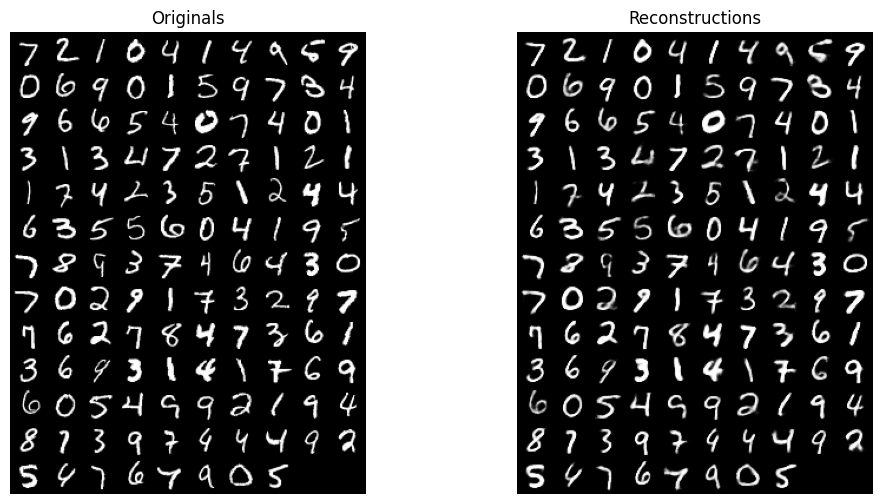

In [13]:
# Make grids
orig_grid  = make_grid(imgs,  nrow=10, normalize=True)
recon_grid = make_grid(recon, nrow=10, normalize=True)

# Convert to numpy for plt
orig_np  = orig_grid.permute(1, 2, 0)
recon_np = recon_grid.permute(1, 2, 0).cpu().numpy()

# Plot side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Originals")
plt.imshow(orig_np, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructions")
plt.imshow(recon_np, cmap="gray")
plt.axis("off")

In [27]:
x = train_dataset.data.float().to(device)

l = train_dataset.targets.float().to(device)

x = x.view(x.shape[0], -1)

x.shape

with torch.no_grad():
    recon, mu, log_var, z = model(x, False)

print(x.shape)
print(labels.shape)
print(z.shape)


torch.Size([60000, 784])
torch.Size([60000])
torch.Size([60000, 200])


In [15]:
print(f"z-mean: {z.mean().item()}")
print(f"z-standard deviation: {z.std().item()}")

z-mean: 2.386881113052368
z-standard deviation: 80.13561248779297


In [16]:
tsne = TSNE(n_components=2, random_state=0)
z_emb = tsne.fit_transform(z.cpu())

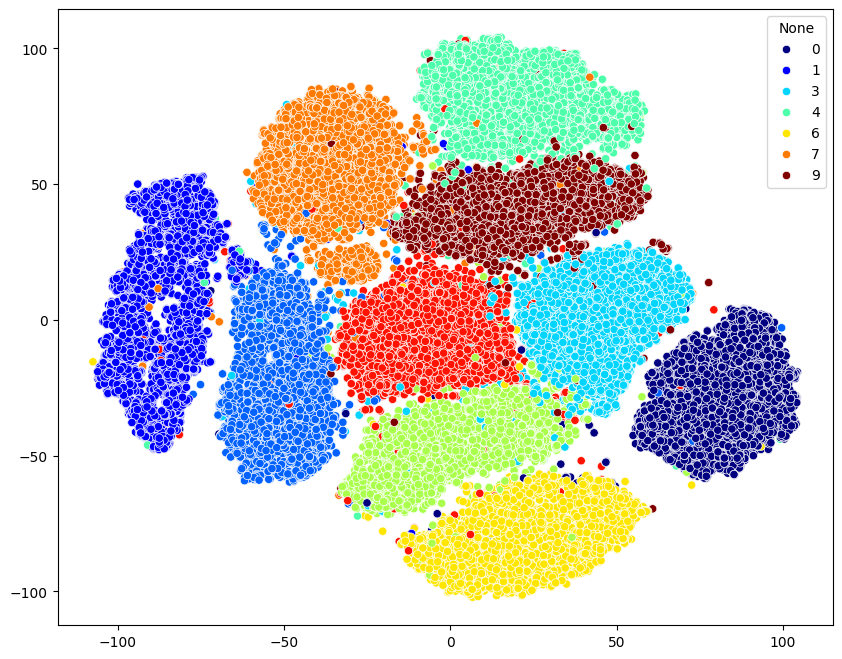

In [17]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=z_emb[:, 0], y=z_emb[:, 1], hue=train_dataset.targets, palette=cm.jet);